In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("hotel_price_dataset.csv")
df

,city,rating,rooms,distance_from_center_km,amenities_count,price
0,Delhi,3.1,91,10.6,2,5854.0
1,Hyderabad,4.9,120,2.5,10,11317.0
2,Delhi,4.2,62,9.3,13,8659.0
3,Chennai,3.8,33,8.3,12,8161.0
4,Hyderabad,2.5,163,3.4,7,6373.0
5,Chennai,2.5,197,14.2,14,5661.0
6,Bangalore,2.2,133,9.2,4,4613.0
7,Hyderabad,4.6,50,10.6,5,8006.0
8,Bangalore,3.8,166,13.3,13,6951.0
9,Delhi,4.1,24,9.6,12,8439.0


In [4]:
df.head()

,city,rating,rooms,distance_from_center_km,amenities_count,price
0,Delhi,3.1,91,10.6,2,5854.0
1,Hyderabad,4.9,120,2.5,10,11317.0
2,Delhi,4.2,62,9.3,13,8659.0
3,Chennai,3.8,33,8.3,12,8161.0
4,Hyderabad,2.5,163,3.4,7,6373.0


In [5]:
df.tail(10)

,city,rating,rooms,distance_from_center_km,amenities_count,price
50,Delhi,4.9,146,7.0,4,9079.0
51,Bangalore,4.3,24,8.5,4,8014.0
52,Kolkata,4.8,99,9.1,5,8942.0
53,Chennai,4.7,51,1.7,9,10547.0
54,Mumbai,3.8,133,5.9,7,8495.0
55,Mumbai,4.8,188,4.0,9,10082.0
56,Bangalore,2.3,72,12.1,2,3756.0
57,Mumbai,2.6,105,7.3,9,6065.0
58,Delhi,2.1,61,14.8,5,3466.0
59,Chennai,3.0,105,6.3,12,7737.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city                     60 non-null     object 
 1   rating                   60 non-null     float64
 2   rooms                    60 non-null     int64  
 3   distance_from_center_km  60 non-null     float64
 4   amenities_count          60 non-null     int64  
 5   price                    60 non-null     float64
dtypes: float64(3), int64(2), object(1)
memory usage: 2.9+ KB


In [7]:
df.describe()

,rating,rooms,distance_from_center_km,amenities_count,price
count,60.000000,60.000000,60.000000,60.000000,60.000000
mean,3.405000,96.616667,7.090000,7.566667,7455.000000
std,0.913816,53.474560,3.854414,3.697762,1739.968887
min,2.100000,10.000000,0.500000,2.000000,3466.000000
25%,2.600000,50.000000,4.075000,4.000000,6056.250000
50%,3.350000,97.500000,6.500000,8.000000,7647.500000
75%,4.125000,144.250000,9.750000,10.250000,8475.500000
max,4.900000,197.000000,15.000000,14.000000,11317.000000


In [8]:
city_counts = df['city'].value_counts()

for city, count in city_counts.items():
    print(f"{city} is repeated {count} times")


Delhi is repeated 13 times
Chennai is repeated 11 times
Mumbai is repeated 11 times
Bangalore is repeated 9 times
Hyderabad is repeated 8 times
Kolkata is repeated 8 times


In [9]:
df.isnull().sum()

city                       0
rating                     0
rooms                      0
distance_from_center_km    0
amenities_count            0
price                      0
dtype: int64

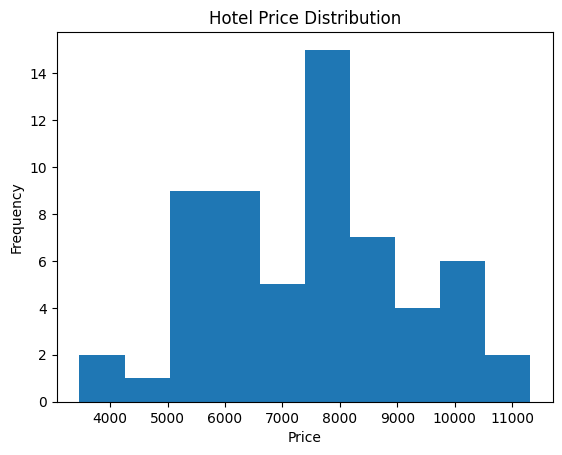

In [10]:
plt.hist(df['price'])
plt.title("Hotel Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.savefig("hotel_price_distribution.png")
plt.show()


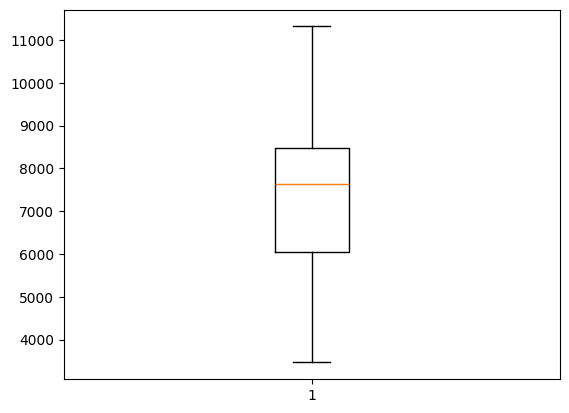

In [11]:
plt.boxplot(df["price"])
plt.savefig("hotel_price_distribution1.png")
plt.show()

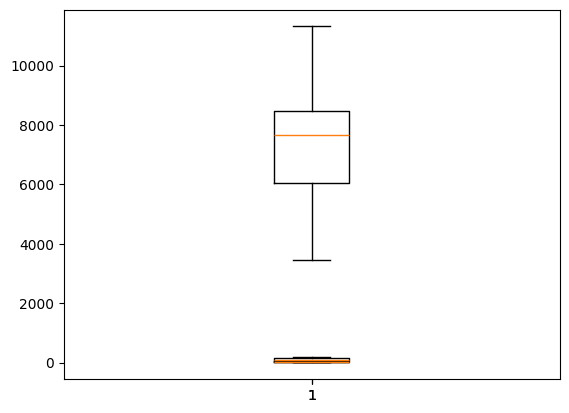

In [12]:
plt.boxplot(df["price"])
plt.boxplot(df["rating"])
plt.boxplot(df["rooms"])

plt.savefig("hotel_price_distribution2.png")
plt.show()

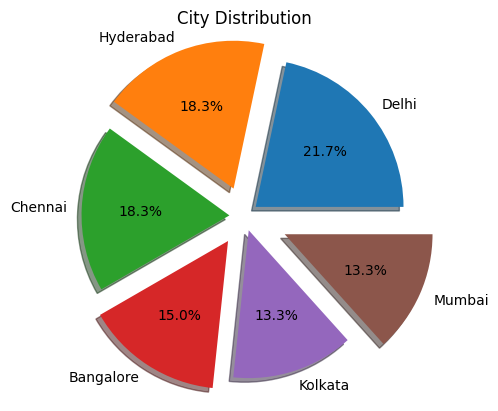

In [13]:
plt.pie(
    df['city'].value_counts(),
    labels=df['city'].unique(),
    autopct='%1.1f%%',
    explode=[0.1, 0.2, 0.1, 0.2, 0.1, 0.3],
    shadow=True
)
plt.savefig("hotel_price_distribution3.png")
plt.title("City Distribution")
plt.show()


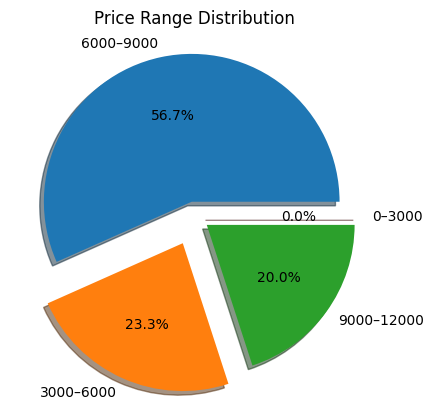

In [14]:
price_bins = [0, 3000, 6000, 9000, 12000]
price_labels = ['0–3000', '3000–6000', '6000–9000', '9000–12000']

df['price_range'] = pd.cut(df['price'], bins=price_bins, labels=price_labels)

plt.pie(
    df['price_range'].value_counts(),
    labels=df['price_range'].value_counts().index,
    autopct='%1.1f%%',
    shadow=True,
    explode=[0.1, 0.2, 0.1, 0.1]
)
plt.savefig("hotel_price_distribution4.png")
plt.title("Price Range Distribution")
plt.show()


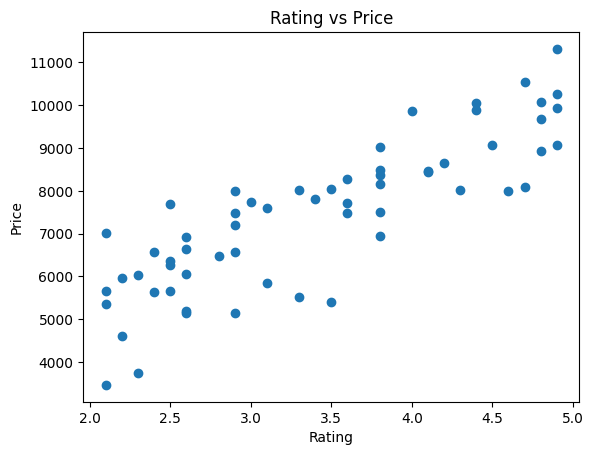

In [15]:

plt.scatter(df['rating'], df['price'])
plt.title("Rating vs Price")
plt.xlabel("Rating")
plt.ylabel("Price")
plt.savefig("hotel_price_distribution.png")
plt.show()


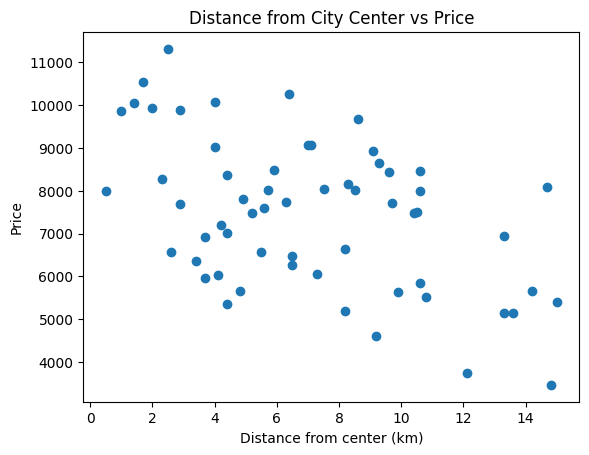

In [16]:
plt.scatter(df['distance_from_center_km'], df['price'])
plt.title("Distance from City Center vs Price")
plt.xlabel("Distance from center (km)")
plt.ylabel("Price")
plt.savefig("hotel_price_distribution6.png")
plt.show()


In [17]:
from sklearn.preprocessing import LabelEncoder
import joblib

le = LabelEncoder()
df['city'] = le.fit_transform(df['city'])

# Save the fitted LabelEncoder
joblib.dump(le, 'city_encoder.pkl')

df.head()

,city,rating,rooms,distance_from_center_km,amenities_count,price,price_range
0,2,3.1,91,10.6,2,5854.0,3000–6000
1,3,4.9,120,2.5,10,11317.0,9000–12000
2,2,4.2,62,9.3,13,8659.0,6000–9000
3,1,3.8,33,8.3,12,8161.0,6000–9000
4,3,2.5,163,3.4,7,6373.0,6000–9000


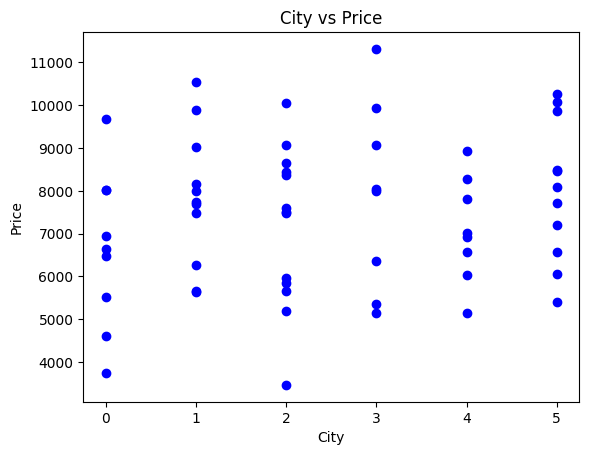

In [18]:
# Scatter Plot

plt.scatter(df["city"], df["price"], color = "Blue")
plt.title("City vs Price")
plt.xlabel("City")
plt.ylabel("Price")
plt.savefig("hotel_price_distribution7.png")
plt.show()

In [19]:
df.values

array([[2, 3.1, 91, 10.6, 2, 5854.0, '3000–6000'],
       [3, 4.9, 120, 2.5, 10, 11317.0, '9000–12000'],
       [2, 4.2, 62, 9.3, 13, 8659.0, '6000–9000'],
       [1, 3.8, 33, 8.3, 12, 8161.0, '6000–9000'],
       [3, 2.5, 163, 3.4, 7, 6373.0, '6000–9000'],
       [1, 2.5, 197, 14.2, 14, 5661.0, '3000–6000'],
       [0, 2.2, 133, 9.2, 4, 4613.0, '3000–6000'],
       [3, 4.6, 50, 10.6, 5, 8006.0, '6000–9000'],
       [0, 3.8, 166, 13.3, 13, 6951.0, '6000–9000'],
       [2, 4.1, 24, 9.6, 12, 8439.0, '6000–9000'],
       [2, 2.1, 54, 4.8, 5, 5662.0, '3000–6000'],
       [3, 4.9, 74, 2.0, 4, 9948.0, '9000–12000'],
       [3, 4.5, 98, 7.1, 11, 9082.0, '9000–12000'],
       [4, 2.6, 80, 3.7, 4, 6920.0, '6000–9000'],
       [1, 2.5, 18, 6.5, 4, 6263.0, '6000–9000'],
       [4, 2.6, 97, 13.3, 5, 5135.0, '3000–6000'],
       [1, 2.9, 138, 5.2, 8, 7487.0, '6000–9000'],
       [4, 3.6, 145, 2.3, 5, 8277.0, '6000–9000'],
       [0, 3.3, 72, 5.7, 10, 8015.0, '6000–9000'],
       [3, 2.9, 148, 13.6,

In [20]:
df.shape

(60, 7)

In [21]:
X = df.drop(['price', 'price_range'], axis=1)
y = df['price']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

print("R² Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("MSE      :", mean_squared_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))


R² Score : 0.9225586219485408
MAE      : 354.68736224827916
MSE      : 164350.29315777883
RMSE     : 405.40139757748597


In [25]:
sample = [[2, 4.5, 80, 5.0, 10]]
pred = model.predict(sample)
print("Predicted Hotel Price:", pred)


Predicted Hotel Price: [9709.79626069]


C:\Users\Pathan Umar\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import joblib
import pandas as pd

df = pd.read_csv("hotel_price_dataset.csv")

X = df[["city", "rating", "rooms", "distance_from_center_km", "amenities_count"]]
y = df["price"]

# Categorical + numerical split
preprocessor = ColumnTransformer([
    ("city_encoder", OneHotEncoder(), ["city"])
], remainder='passthrough')

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regression", LinearRegression())
])

model.fit(X, y)

joblib.dump(model, "hotel_price_model.pkl")


['hotel_price_model.pkl']

In [27]:
import joblib
import pandas as pd

model = joblib.load("hotel_price_model.pkl")

input_data = pd.DataFrame({
    "city": ["Mumbai"],
    "rating": [4.5],
    "rooms": [2],
    "distance_from_center_km": [3.0],
    "amenities_count": [4]
})

prediction = model.predict(input_data)
print("Predicted price:", prediction[0])


Predicted price: 9378.605987214845


In [28]:
df.head()

,city,rating,rooms,distance_from_center_km,amenities_count,price
0,Delhi,3.1,91,10.6,2,5854.0
1,Hyderabad,4.9,120,2.5,10,11317.0
2,Delhi,4.2,62,9.3,13,8659.0
3,Chennai,3.8,33,8.3,12,8161.0
4,Hyderabad,2.5,163,3.4,7,6373.0


In [29]:
df.tail(5)

,city,rating,rooms,distance_from_center_km,amenities_count,price
55,Mumbai,4.8,188,4.0,9,10082.0
56,Bangalore,2.3,72,12.1,2,3756.0
57,Mumbai,2.6,105,7.3,9,6065.0
58,Delhi,2.1,61,14.8,5,3466.0
59,Chennai,3.0,105,6.3,12,7737.0


In [30]:
city_encoder = joblib.load("city_encoder.pkl")


In [31]:
print(city_encoder.classes_)


['Bangalore' 'Chennai' 'Delhi' 'Hyderabad' 'Kolkata' 'Mumbai']


In [32]:
import joblib

# Save model
joblib.dump(model, "model.pkl")

# Save city encoder
joblib.dump(city_encoder, "city_encoder.pkl")


['city_encoder.pkl']